# JitGen Paper Artifacts

This notebook generates all figures and tables for the JitGen research paper.  
It compares **async (JitGen)** — incremental, streaming code execution — against **sync (sequential)** — traditional generate-then-execute — across 5 LLMs on the MBPP benchmark.

**Outputs:**
- `images/` — PNG figures at 300 DPI
- `tables/` — CSV summary tables

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths ──────────────────────────────────────────────────────────────
RESULTS_DIR = Path("../evaluation/results")
IMAGES_DIR = Path("images")
TABLES_DIR = Path("tables")
IMAGES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
PALETTE = {"Async": "#4C72B0", "Sync": "#DD8452"}
ALGO_ORDER = ["Async", "Sync"]

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
})

MODEL_LABELS = {
    "gemma3_latest": "Gemma 3",
    "llama3_2_latest": "Llama 3.2",
    "phi4_latest": "Phi 4",
    "gpt-oss_20b": "GPT-OSS 20B",
    "qwen3-coder_30b": "Qwen3-Coder 30B",
    "xingyaow__codeact-agent-mistral": "CodeAct-Mistral",
}
MODEL_ORDER = ["Gemma 3", "Llama 3.2", "Phi 4", "GPT-OSS 20B", "Qwen3-Coder 30B", "CodeAct-Mistral"]

print("Setup complete")

Setup complete


In [2]:
def _extract_model_key(filename_stem: str) -> str:
    """Extract model key from filename by matching against known MODEL_LABELS keys.

    Handles variable-length model names like 'llama3_2_latest' (3 tokens)
    vs 'gemma3_latest' (2 tokens).
    """
    for n_tokens in range(4, 0, -1):  # try longest match first
        parts = filename_stem.split("_")
        candidate = "_".join(parts[:n_tokens])
        if candidate in MODEL_LABELS:
            return candidate
    # Fallback: first two tokens
    return "_".join(filename_stem.split("_")[:2])


def load_benchmark_df(results_dir: Path) -> pd.DataFrame:
    """Load all benchmark CSVs into a single DataFrame with ModelName and Algorithm columns."""
    frames = []
    for csv_path in sorted(results_dir.glob("*.csv")):
        model_key = _extract_model_key(csv_path.stem)
        algorithm = "Async" if "async" in csv_path.stem else "Sync"
        frame = pd.read_csv(csv_path)
        frame["ModelName"] = model_key
        frame["Algorithm"] = algorithm
        frames.append(frame)
    df_all = pd.concat(frames, ignore_index=True)
    df_all["ModelLabel"] = df_all["ModelName"].map(MODEL_LABELS)
    return df_all


df = load_benchmark_df(RESULTS_DIR)

# Build paired delta DataFrame — each RowID may appear multiple times (multiple test cases)
# Use cumcount within (Model, Algorithm, RowID) to create a sub-index for proper pairing
paired_frames = []
for model in df["ModelLabel"].unique():
    df_model = df[df["ModelLabel"] == model].copy()
    df_model["SubIdx"] = df_model.groupby(["Algorithm", "RowID"]).cumcount()

    df_async = df_model[df_model["Algorithm"] == "Async"].copy()
    df_sync = df_model[df_model["Algorithm"] == "Sync"].copy()

    merged = df_async.merge(
        df_sync,
        on=["RowID", "SubIdx"],
        suffixes=("_async", "_sync"),
        how="inner",
    )
    paired = pd.DataFrame({
        "RowID": merged["RowID"],
        "ModelLabel": model,
        "AsyncExecTime": merged["ExecutionTime_async"].values,
        "SyncExecTime": merged["ExecutionTime_sync"].values,
        "AsyncFirstOutput": merged["FirstOutput_async"].values,
        "SyncFirstOutput": merged["FirstOutput_sync"].values,
        "AsyncCorrect": merged["CorrectOutput_async"].values,
        "SyncCorrect": merged["CorrectOutput_sync"].values,
        "AsyncError": merged["ErrorOccurred_async"].values,
        "SyncError": merged["ErrorOccurred_sync"].values,
    })
    paired["DeltaExecTime"] = paired["AsyncExecTime"] - paired["SyncExecTime"]
    paired["DeltaFirstOutput"] = paired["AsyncFirstOutput"] - paired["SyncFirstOutput"]
    paired["SpeedupFirstOutput"] = paired["SyncFirstOutput"] / paired["AsyncFirstOutput"]
    paired_frames.append(paired)

df_paired = pd.concat(paired_frames, ignore_index=True)

print(f"Loaded {len(df)} rows from {df['ModelName'].nunique()} models")
print(f"Paired observations: {len(df_paired)}")
print(f"Models: {', '.join(df['ModelLabel'].dropna().unique())}")
print(f"\nPer-model row counts:")
print(df.groupby(["ModelLabel", "Algorithm"]).size().unstack(fill_value=0))
df.head()

Loaded 1356 rows from 6 models
Paired observations: 565
Models: Gemma 3, GPT-OSS 20B, Llama 3.2, Phi 4, Qwen3-Coder 30B

Per-model row counts:
Algorithm        Async  Sync
ModelLabel                  
GPT-OSS 20B        113   113
Gemma 3            113   113
Llama 3.2          113   113
Phi 4              113   113
Qwen3-Coder 30B    113   113


,RowID,ErrorOccurred,ExecutionOutput,HasTimedOut,ExecutionError,ExecutionTime,ExpectedOutput,ActualOutput,CorrectOutput,FirstOutput,ModelName,Algorithm,ModelLabel
0,511,False,192\r\n,False,NaN,2.470870,15,192,False,1.985238,gemma3_latest,Async,Gemma 3
1,511,False,7\r\n,False,NaN,2.237782,2,7,False,1.992164,gemma3_latest,Async,Gemma 3
2,512,False,"{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}\r\n",False,NaN,2.958128,"{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}","{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}",True,2.128772,gemma3_latest,Async,Gemma 3
3,512,False,"{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}\r\n",False,NaN,2.731242,"{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}","{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}",True,2.124765,gemma3_latest,Async,Gemma 3
4,513,False,"[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']\r\n",False,NaN,2.308076,"[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']","[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']",True,2.008135,gemma3_latest,Async,Gemma 3


In [34]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 1 — Summary Statistics (Execution Time & First Output)
# ══════════════════════════════════════════════════════════════════════
summary = (
    df.groupby(["ModelLabel", "Algorithm"])
    .agg(
        Count=("ExecutionTime", "size"),
        ExecTime_Mean=("ExecutionTime", "mean"),
        ExecTime_Median=("ExecutionTime", "median"),
        ExecTime_Std=("ExecutionTime", "std"),
        FirstOutput_Mean=("FirstOutput", "mean"),
        FirstOutput_Median=("FirstOutput", "median"),
        FirstOutput_Std=("FirstOutput", "std"),
    )
    .round(3)
)
summary.to_csv(TABLES_DIR / "summary_statistics.csv")
print("Saved tables/summary_statistics.csv")
summary

Saved tables/summary_statistics.csv


Count  ExecTime_Mean  ExecTime_Median  \
ModelLabel      Algorithm                                          
GPT-OSS 20B     Async        113         20.523            8.295   
                Sync         113         20.464            8.301   
Gemma 3         Async        113          2.516            2.442   
                Sync         113          2.565            2.486   
Llama 3.2       Async        113          2.101            1.969   
                Sync         113          1.992            1.930   
Phi 4           Async        113          3.969            3.864   
                Sync         113          3.886            3.884   
Qwen3-Coder 30B Async        113          6.232            4.696   
                Sync         113          6.100            4.642   

                           ExecTime_Std  FirstOutput_Mean  FirstOutput_Median  \
ModelLabel      Algorithm                                                       
GPT-OSS 20B     Async            32.635            20.179               7.958   
                Sync             32.636            20.464               8.300   
Gemma 3         Async             0.444             2.081               2.055   
                Sync              0.327             2.565               2.485   
Llama 3.2       Async             0.778             1.821               1.659   
                Sync              0.231             1.992               1.930   
Phi 4           Async             0.983             3.395               3.263   
                Sync              0.805             3.886               3.884   
Qwen3-Coder 30B Async             4.852             5.232               4.027   
                Sync              4.019             6.100               4.642   

                           FirstOutput_Std  
ModelLabel      Algorithm                   
GPT-OSS 20B     Async               32.730  
                Sync                32.636  
Gemma 3         Async                0.273  
                Sync                 0.327  
Llama 3.2       Async                0.765  
                Sync                 0.231  
Phi 4           Async                0.823  
                Sync                 0.805  
Qwen3-Coder 30B Async                2.967  
                Sync                 4.019

In [35]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 2 — Pass Rate, Correctness Rate, Timeout Rate
# ══════════════════════════════════════════════════════════════════════
pass_correct = (
    df.groupby(["ModelLabel", "Algorithm"])
    .agg(
        Count=("RowID", "size"),
        PassRate=("ErrorOccurred", lambda x: (1 - x.mean()) * 100),
        CorrectnessRate=("CorrectOutput", lambda x: x.mean() * 100),
        TimeoutRate=("HasTimedOut", lambda x: x.mean() * 100),
    )
    .round(2)
)
pass_correct.to_csv(TABLES_DIR / "pass_correctness.csv")
print("Saved tables/pass_correctness.csv")
pass_correct

Saved tables/pass_correctness.csv


Count  PassRate  CorrectnessRate  TimeoutRate
ModelLabel      Algorithm                                               
GPT-OSS 20B     Async        113    100.00            58.41          0.0
                Sync         113    100.00            58.41          0.0
Gemma 3         Async        113     98.23            54.87          0.0
                Sync         113     98.23            54.87          0.0
Llama 3.2       Async        113     85.84            30.97          0.0
                Sync         113     86.73            30.97          0.0
Phi 4           Async        113     99.12            71.68          0.0
                Sync         113     99.12            71.68          0.0
Qwen3-Coder 30B Async        113     99.12            77.88          0.0
                Sync         113     99.12            77.88          0.0

In [36]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 3 — Statistical Tests (Wilcoxon signed-rank, paired)
# ══════════════════════════════════════════════════════════════════════
def rank_biserial(w_stat, n):
    """Rank-biserial correlation as effect size for Wilcoxon test."""
    return 1 - (2 * w_stat) / (n * (n + 1) / 2)


test_rows = []
n_tests = 0
for model in MODEL_ORDER:
    mp = df_paired[df_paired["ModelLabel"] == model]
    for metric, col in [("ExecutionTime", "DeltaExecTime"), ("FirstOutput", "DeltaFirstOutput")]:
        deltas = mp[col].dropna()
        # Remove zero differences (Wilcoxon cannot handle them)
        deltas_nz = deltas[deltas != 0]
        n = len(deltas_nz)
        if n < 10:
            test_rows.append({
                "Model": model, "Metric": metric,
                "N": n, "MeanDelta": deltas.mean(), "MedianDelta": deltas.median(),
                "W": np.nan, "p_value": np.nan, "p_corrected": np.nan,
                "EffectSize_r": np.nan, "Significant": "N/A (n<10)",
            })
            n_tests += 1
            continue
        w, p = stats.wilcoxon(deltas_nz, alternative="two-sided")
        r = rank_biserial(w, n)
        n_tests += 1
        test_rows.append({
            "Model": model, "Metric": metric,
            "N": n, "MeanDelta": round(deltas.mean(), 4),
            "MedianDelta": round(deltas.median(), 4),
            "W": w, "p_value": p, "p_corrected": None,
            "EffectSize_r": round(r, 4), "Significant": None,
        })

# Bonferroni correction
alpha = 0.05
for row in test_rows:
    if row["p_value"] is not None and not np.isnan(row["p_value"]):
        row["p_corrected"] = min(row["p_value"] * n_tests, 1.0)
        row["Significant"] = "Yes" if row["p_corrected"] < alpha else "No"

df_tests = pd.DataFrame(test_rows)
df_tests.to_csv(TABLES_DIR / "statistical_tests.csv", index=False)
print("Saved tables/statistical_tests.csv")
df_tests

Saved tables/statistical_tests.csv


,Model,Metric,N,MeanDelta,MedianDelta,W,p_value,p_corrected,EffectSize_r,Significant
0,Gemma 3,ExecutionTime,113,-0.0488,-0.0522,803.0,4.336367e-12,4.336367e-11,0.7507,Yes
1,Gemma 3,FirstOutput,113,-0.4840,-0.4455,8.0,3.470809e-20,3.470809e-19,0.9975,Yes
2,Llama 3.2,ExecutionTime,113,0.1086,0.0087,2222.0,4.229106e-03,4.229106e-02,0.3100,Yes
3,Llama 3.2,FirstOutput,113,-0.1713,-0.2139,248.0,1.655154e-17,1.655154e-16,0.9230,Yes
4,Phi 4,ExecutionTime,113,0.0834,0.0153,1715.0,1.610371e-05,1.610371e-04,0.4675,Yes
5,Phi 4,FirstOutput,113,-0.4903,-0.4470,221.0,8.465314e-18,8.465314e-17,0.9314,Yes
6,GPT-OSS 20B,ExecutionTime,113,0.0587,0.0015,2763.0,1.899705e-01,1.000000e+00,0.1421,No
7,GPT-OSS 20B,FirstOutput,113,-0.2851,-0.2887,653.0,1.902307e-13,1.902307e-12,0.7972,Yes
8,Qwen3-Coder 30B,ExecutionTime,113,0.1321,0.0037,2792.0,2.196025e-01,1.000000e+00,0.1331,No
9,Qwen3-Coder 30B,FirstOutput,113,-0.8680,-0.4104,225.0,9.352873e-18,9.352873e-17,0.9301,Yes


In [37]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 4 — Error Type Breakdown
# ══════════════════════════════════════════════════════════════════════
import re

def classify_error(row):
    if not row["ErrorOccurred"]:
        return "Success"
    if row["HasTimedOut"]:
        return "Timeout"
    err = str(row.get("ExecutionError", ""))
    if "input()" in err or "input() function" in err:
        return "Disabled input()"
    if "TypeError" in err or "not callable" in err or "not iterable" in err:
        return "TypeError"
    if "IndexError" in err or "not subscriptable" in err or "pop from empty" in err:
        return "IndexError"
    if "NameError" in err:
        return "NameError"
    if "SyntaxError" in err:
        return "SyntaxError"
    if "ValueError" in err:
        return "ValueError"
    if "AttributeError" in err:
        return "AttributeError"
    if err.strip():
        return "Other Error"
    return "Unknown Error"

df["ErrorCategory"] = df.apply(classify_error, axis=1)

error_breakdown = (
    df.groupby(["ModelLabel", "Algorithm", "ErrorCategory"])
    .size()
    .reset_index(name="Count")
)
error_pivot = error_breakdown.pivot_table(
    index=["ModelLabel", "Algorithm"],
    columns="ErrorCategory",
    values="Count",
    fill_value=0,
)
error_pivot.to_csv(TABLES_DIR / "error_breakdown.csv")
print("Saved tables/error_breakdown.csv")
error_pivot

Saved tables/error_breakdown.csv


ErrorCategory              Disabled input()  IndexError  Other Error  Success  \
ModelLabel      Algorithm                                                       
GPT-OSS 20B     Async                   0.0         0.0          0.0    113.0   
                Sync                    0.0         0.0          0.0    113.0   
Gemma 3         Async                   0.0         0.0          2.0    111.0   
                Sync                    0.0         0.0          2.0    111.0   
Llama 3.2       Async                   5.0         2.0          6.0     97.0   
                Sync                    5.0         2.0          5.0     98.0   
Phi 4           Async                   0.0         0.0          1.0    112.0   
                Sync                    0.0         0.0          1.0    112.0   
Qwen3-Coder 30B Async                   0.0         0.0          1.0    112.0   
                Sync                    0.0         0.0          1.0    112.0   

ErrorCategory              TypeError  
ModelLabel      Algorithm             
GPT-OSS 20B     Async            0.0  
                Sync             0.0  
Gemma 3         Async            0.0  
                Sync             0.0  
Llama 3.2       Async            3.0  
                Sync             3.0  
Phi 4           Async            0.0  
                Sync             0.0  
Qwen3-Coder 30B Async            0.0  
                Sync             0.0

Saved images/correctness_barplot.png


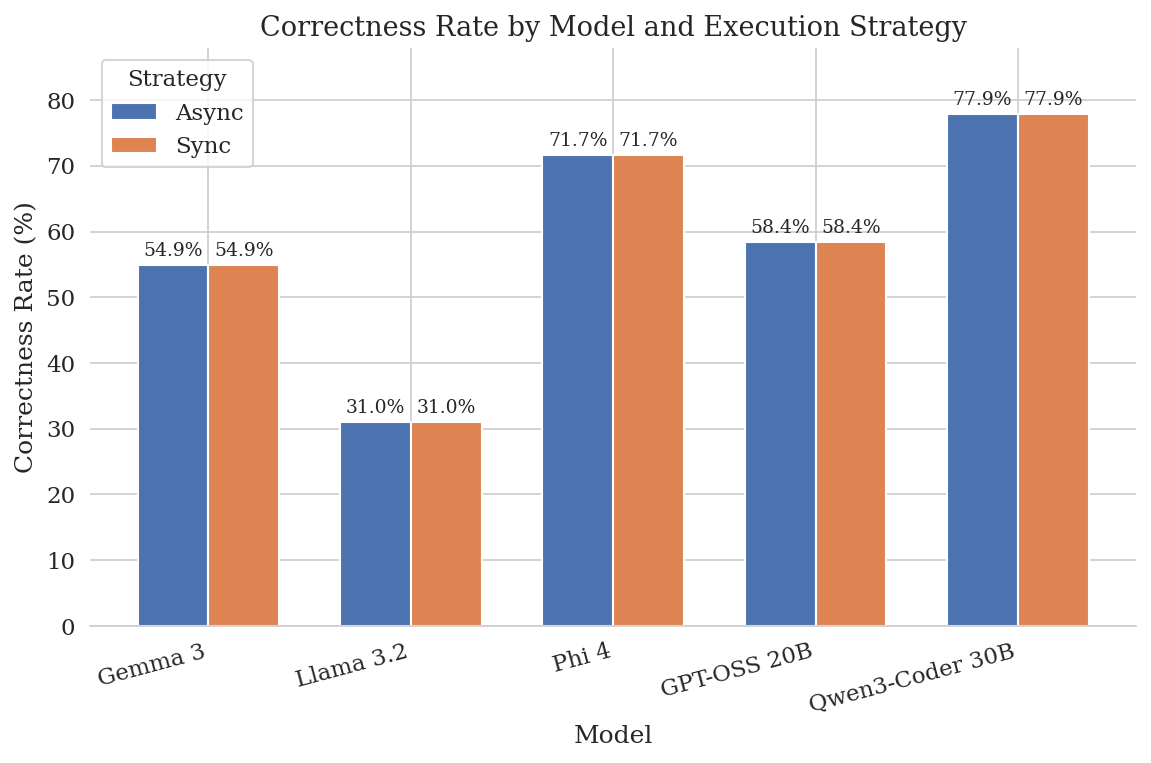

In [38]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — Correctness Rate by Model and Execution Strategy
# ══════════════════════════════════════════════════════════════════════
correct_rates = (
    df.groupby(["ModelLabel", "Algorithm"])["CorrectOutput"]
    .mean()
    .mul(100)
    .reset_index(name="Correctness (%)")
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.35

for i, algo in enumerate(ALGO_ORDER):
    subset = correct_rates[correct_rates["Algorithm"] == algo]
    # Ensure model order
    vals = [subset.loc[subset["ModelLabel"] == m, "Correctness (%)"].values[0]
            if m in subset["ModelLabel"].values else 0
            for m in MODEL_ORDER]
    bars = ax.bar(x + i * width - width / 2, vals, width,
                  label=algo, color=PALETTE[algo], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Model")
ax.set_ylabel("Correctness Rate (%)")
ax.set_title("Correctness Rate by Model and Execution Strategy")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right")
ax.legend(title="Strategy")
ax.set_ylim(0, max(correct_rates["Correctness (%)"]) + 10)
sns.despine(left=True)

fig.savefig(IMAGES_DIR / "correctness_barplot.png")
print("Saved images/correctness_barplot.png")
plt.show()

Saved images/first_output_violin.png


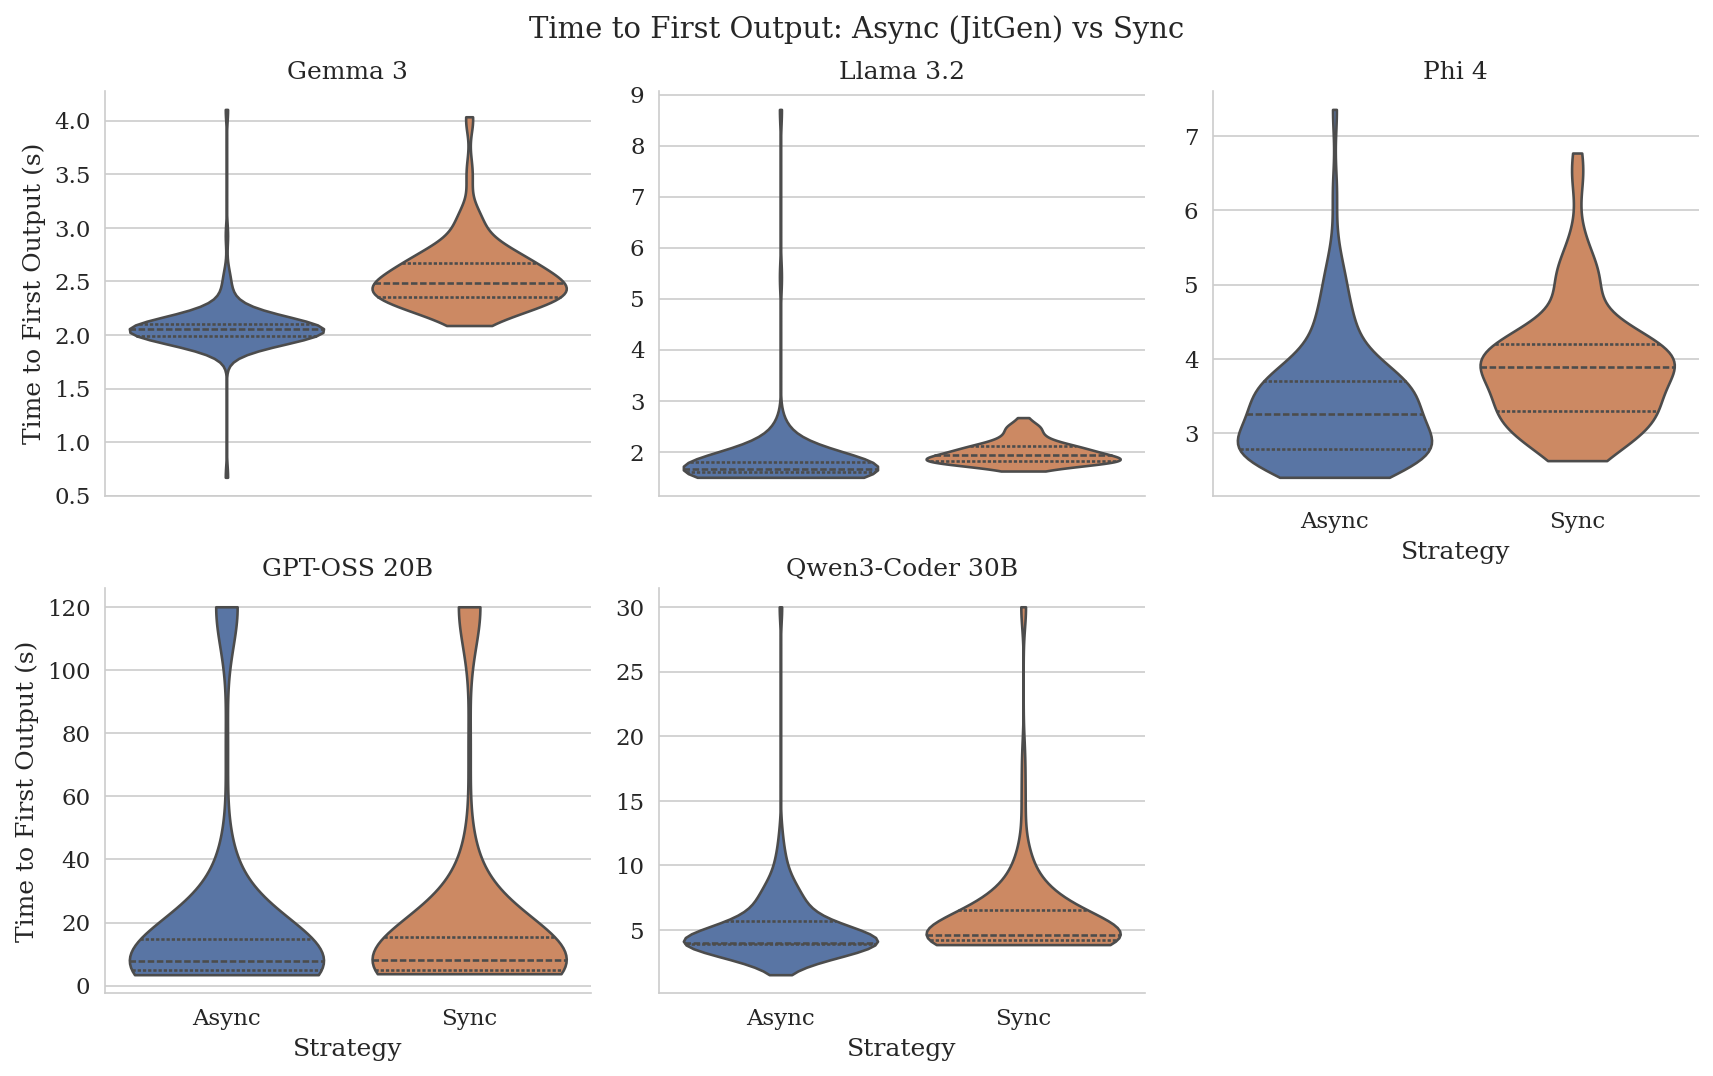

In [39]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Time to First Output: Violin Plots (KEY FIGURE)
# ══════════════════════════════════════════════════════════════════════
g = sns.catplot(
    data=df, x="Algorithm", y="FirstOutput", col="ModelLabel",
    kind="violin", order=ALGO_ORDER, col_order=MODEL_ORDER,
    palette=PALETTE, inner="quartile", cut=0,
    sharey=False, col_wrap=3, height=3.5, aspect=1.1,
)
g.set_titles("{col_name}")
g.set_axis_labels("Strategy", "Time to First Output (s)")
g.figure.suptitle("Time to First Output: Async (JitGen) vs Sync", y=1.02, fontsize=14)

g.savefig(IMAGES_DIR / "first_output_violin.png")
print("Saved images/first_output_violin.png")
plt.show()

Saved images/execution_time_violin.png


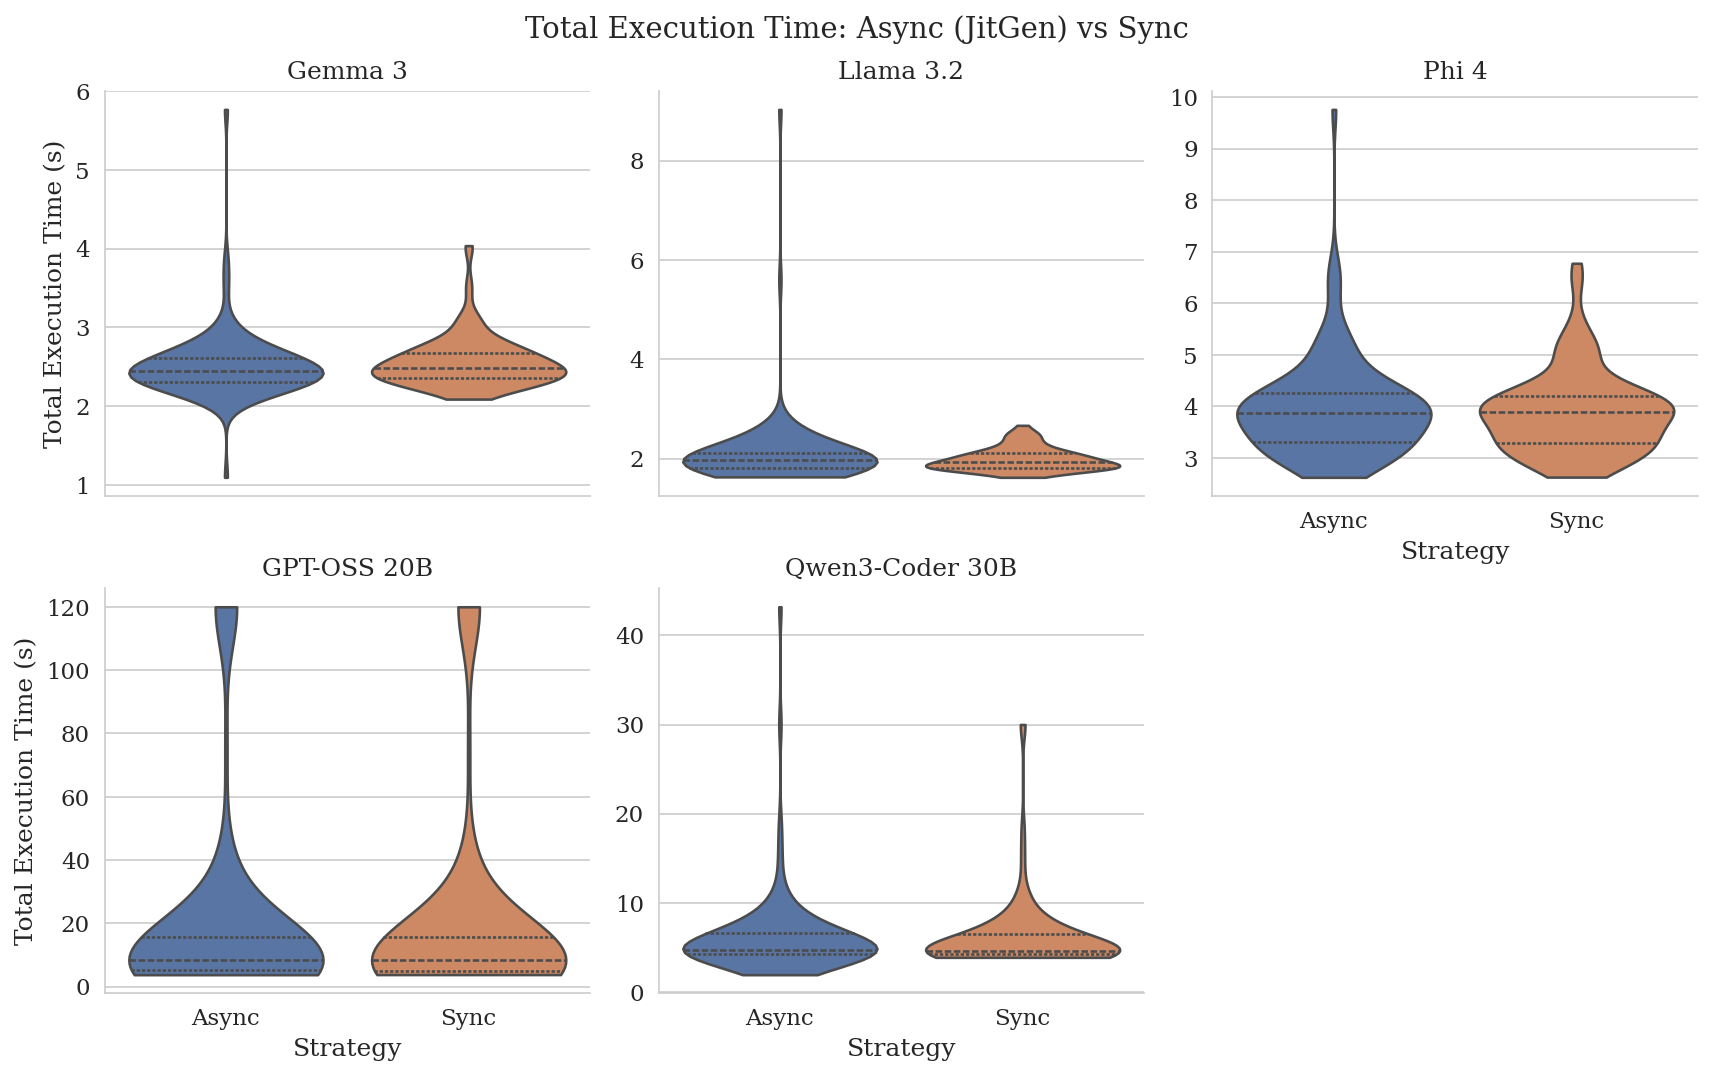

In [40]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 3 — Total Execution Time: Violin Plots
# ══════════════════════════════════════════════════════════════════════
g = sns.catplot(
    data=df, x="Algorithm", y="ExecutionTime", col="ModelLabel",
    kind="violin", order=ALGO_ORDER, col_order=MODEL_ORDER,
    palette=PALETTE, inner="quartile", cut=0,
    sharey=False, col_wrap=3, height=3.5, aspect=1.1,
)
g.set_titles("{col_name}")
g.set_axis_labels("Strategy", "Total Execution Time (s)")
g.figure.suptitle("Total Execution Time: Async (JitGen) vs Sync", y=1.02, fontsize=14)

g.savefig(IMAGES_DIR / "execution_time_violin.png")
print("Saved images/execution_time_violin.png")
plt.show()

Saved images/first_output_ecdf.png


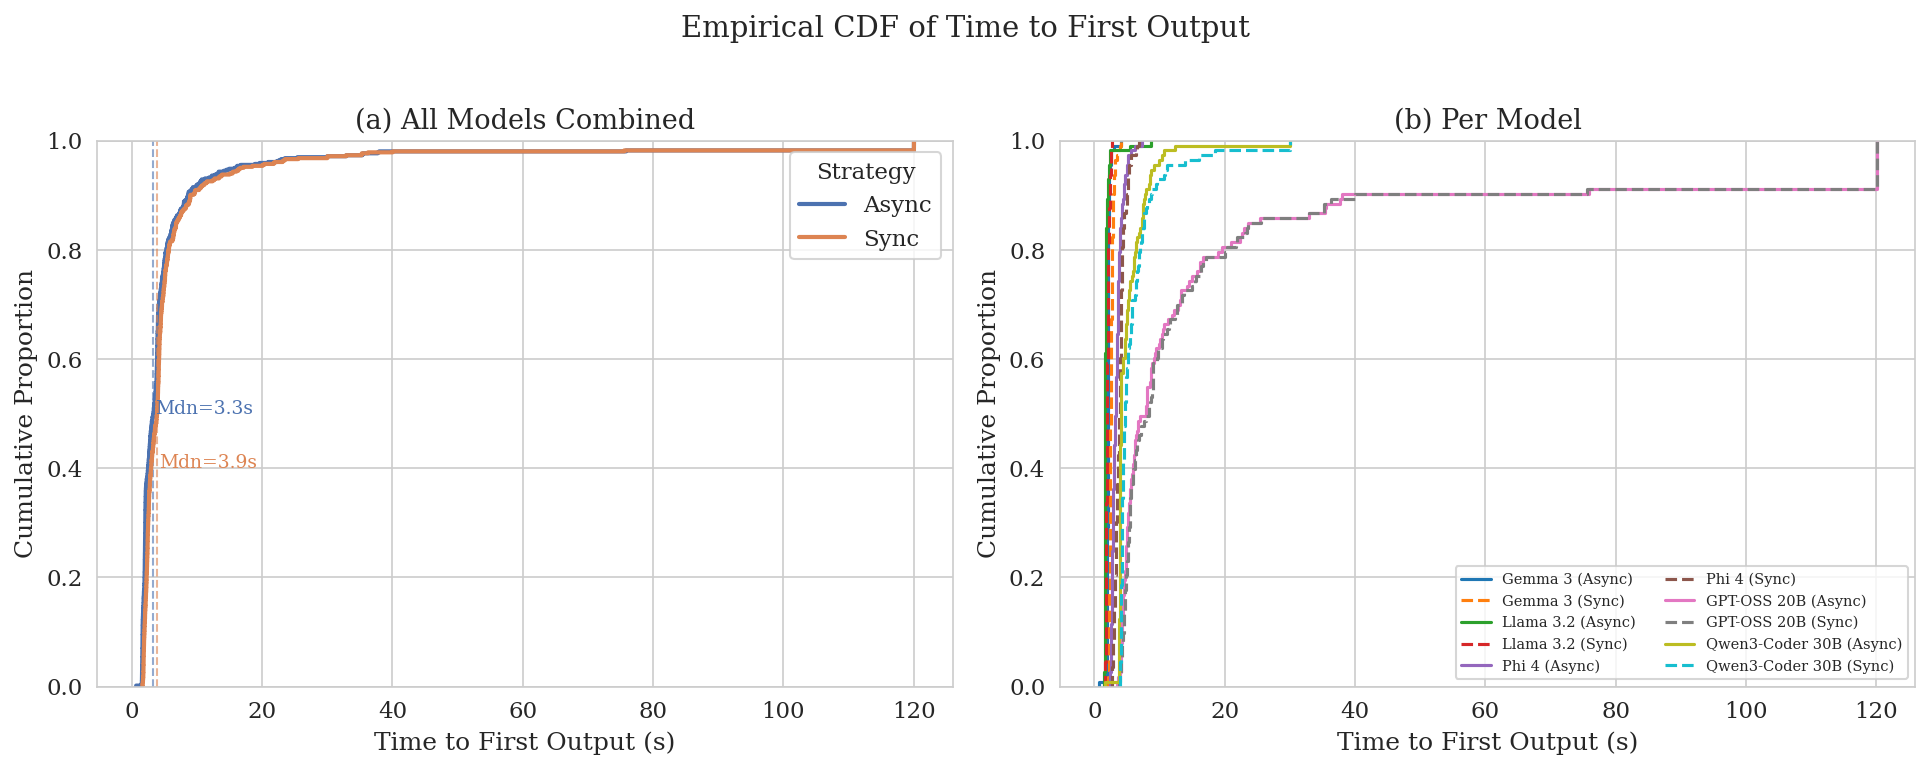

In [41]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 4 — ECDF of First Output Time (aggregate + per model)
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 4a — Aggregate ECDF
ax = axes[0]
for algo in ALGO_ORDER:
    subset = df[df["Algorithm"] == algo]["FirstOutput"]
    sns.ecdfplot(data=subset, ax=ax, label=algo, color=PALETTE[algo], linewidth=2)
    med = subset.median()
    ax.axvline(med, color=PALETTE[algo], linestyle="--", alpha=0.6, linewidth=1)
    ax.text(med + 0.3, 0.5 if algo == "Async" else 0.4,
            f"Mdn={med:.1f}s", color=PALETTE[algo], fontsize=9)

ax.set_xlabel("Time to First Output (s)")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("(a) All Models Combined")
ax.legend(title="Strategy")

# 4b — Per-model ECDF
ax = axes[1]
for model in MODEL_ORDER:
    for algo in ALGO_ORDER:
        subset = df[(df["ModelLabel"] == model) & (df["Algorithm"] == algo)]["FirstOutput"]
        ls = "-" if algo == "Async" else "--"
        sns.ecdfplot(data=subset, ax=ax, label=f"{model} ({algo})",
                     linestyle=ls, linewidth=1.5)

ax.set_xlabel("Time to First Output (s)")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("(b) Per Model")
ax.legend(fontsize=7, ncol=2, loc="lower right")

fig.suptitle("Empirical CDF of Time to First Output", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "first_output_ecdf.png")
print("Saved images/first_output_ecdf.png")
plt.show()

Saved images/delta_first_output_boxplot.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_28060\1028615481.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right")


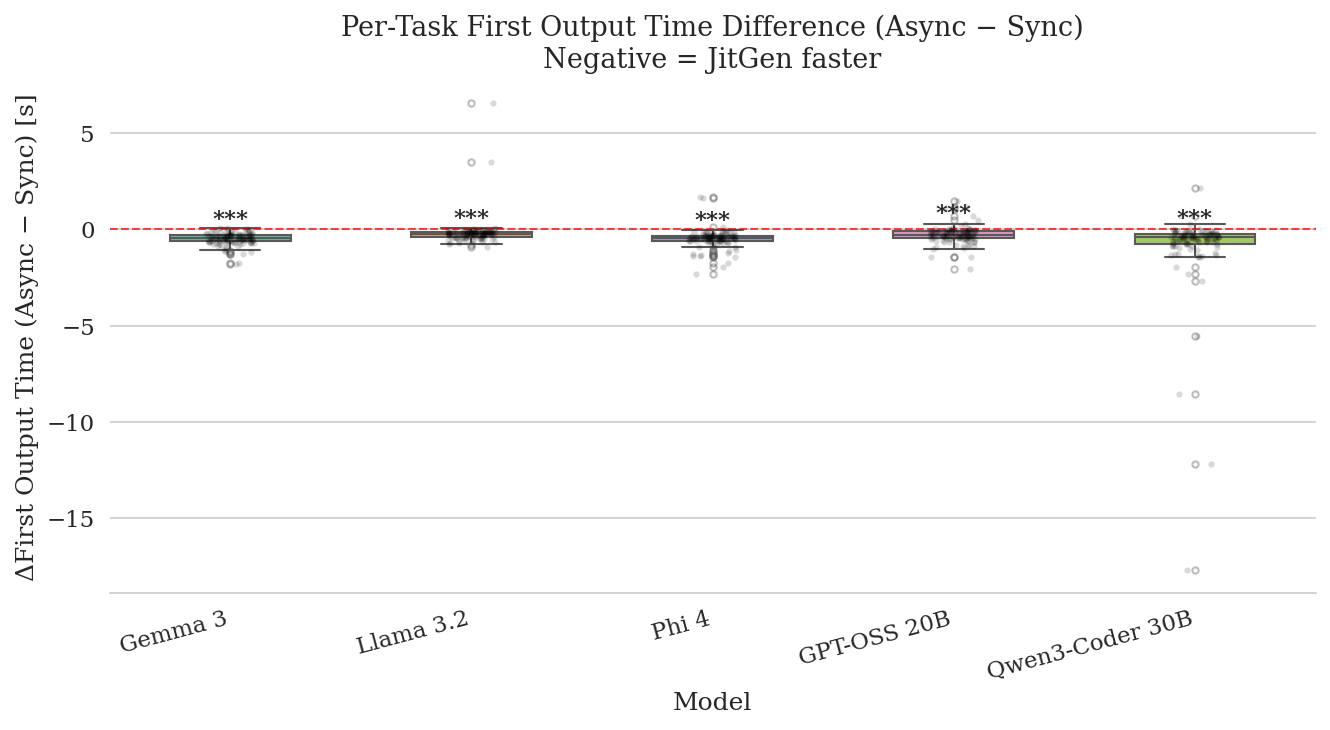

In [42]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 5 — Paired Delta: First Output Time (Async − Sync) with Significance
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df_paired, x="ModelLabel", y="DeltaFirstOutput",
    order=MODEL_ORDER, palette="Set2", ax=ax, width=0.5,
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
sns.stripplot(
    data=df_paired, x="ModelLabel", y="DeltaFirstOutput",
    order=MODEL_ORDER, color="black", alpha=0.15, size=3, jitter=True, ax=ax,
)
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)

# Add significance annotations from the statistical tests
for i, model in enumerate(MODEL_ORDER):
    row = df_tests[(df_tests["Model"] == model) & (df_tests["Metric"] == "FirstOutput")]
    if len(row) == 0:
        continue
    p_corr = row["p_corrected"].values[0]
    if p_corr is None or (isinstance(p_corr, float) and np.isnan(p_corr)):
        label = "n.s."
    elif p_corr < 0.001:
        label = "***"
    elif p_corr < 0.01:
        label = "**"
    elif p_corr < 0.05:
        label = "*"
    else:
        label = "n.s."
    y_max = df_paired[df_paired["ModelLabel"] == model]["DeltaFirstOutput"].quantile(0.95)
    ax.text(i, y_max + 0.3, label, ha="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Model")
ax.set_ylabel("ΔFirst Output Time (Async − Sync) [s]")
ax.set_title("Per-Task First Output Time Difference (Async − Sync)\nNegative = JitGen faster")
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right")
sns.despine(left=True)

fig.tight_layout()
fig.savefig(IMAGES_DIR / "delta_first_output_boxplot.png")
print("Saved images/delta_first_output_boxplot.png")
plt.show()

Saved images/speedup_ratio_barplot.png


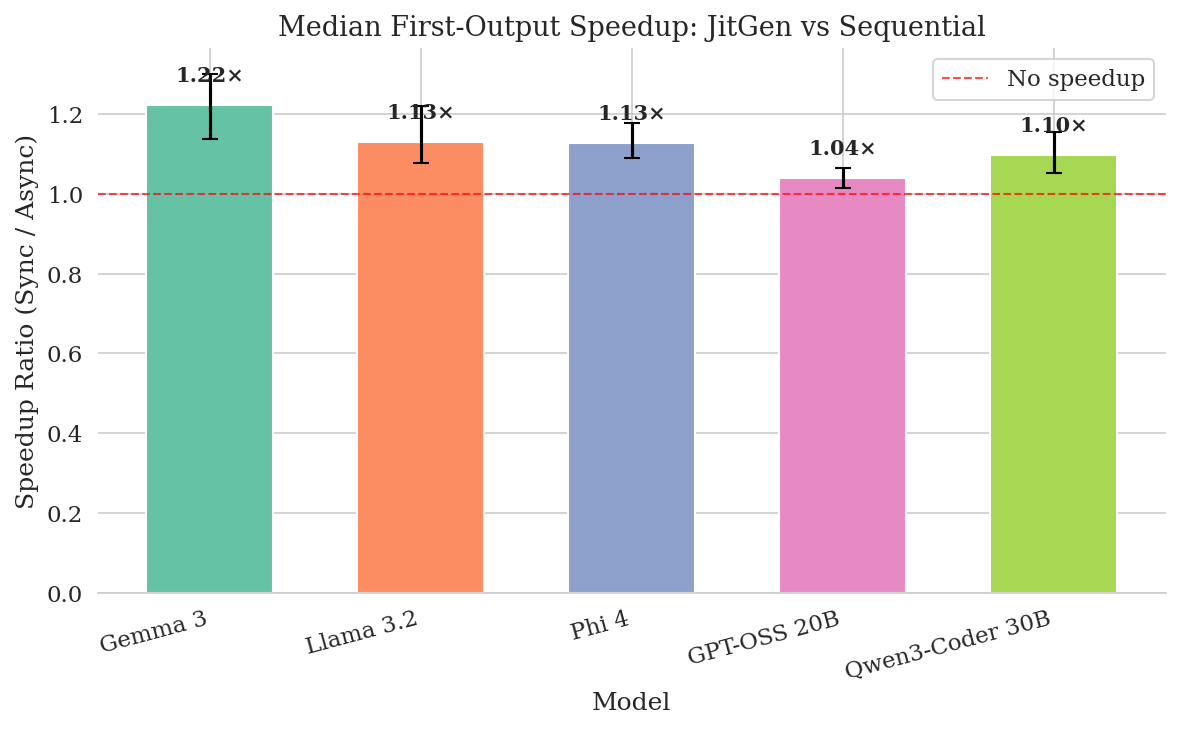

In [43]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 6 — Median First-Output Speedup Ratio per Model
# ══════════════════════════════════════════════════════════════════════
speedup_stats = (
    df_paired.groupby("ModelLabel")["SpeedupFirstOutput"]
    .agg(["median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
)
speedup_stats.columns = ["Median", "Q1", "Q3"]
speedup_stats = speedup_stats.reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODEL_ORDER))
colors = sns.color_palette("Set2", len(MODEL_ORDER))

bars = ax.bar(x, speedup_stats["Median"], color=colors, edgecolor="white", width=0.6)
# Error bars from IQR
ax.errorbar(x, speedup_stats["Median"],
            yerr=[speedup_stats["Median"] - speedup_stats["Q1"],
                  speedup_stats["Q3"] - speedup_stats["Median"]],
            fmt="none", ecolor="black", capsize=4, linewidth=1.5)

ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="No speedup")

for i, (bar, v) in enumerate(zip(bars, speedup_stats["Median"])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{v:.2f}×", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Model")
ax.set_ylabel("Speedup Ratio (Sync / Async)")
ax.set_title("Median First-Output Speedup: JitGen vs Sequential")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right")
ax.legend()
sns.despine(left=True)

fig.tight_layout()
fig.savefig(IMAGES_DIR / "speedup_ratio_barplot.png")
print("Saved images/speedup_ratio_barplot.png")
plt.show()

Saved images/error_distribution.png


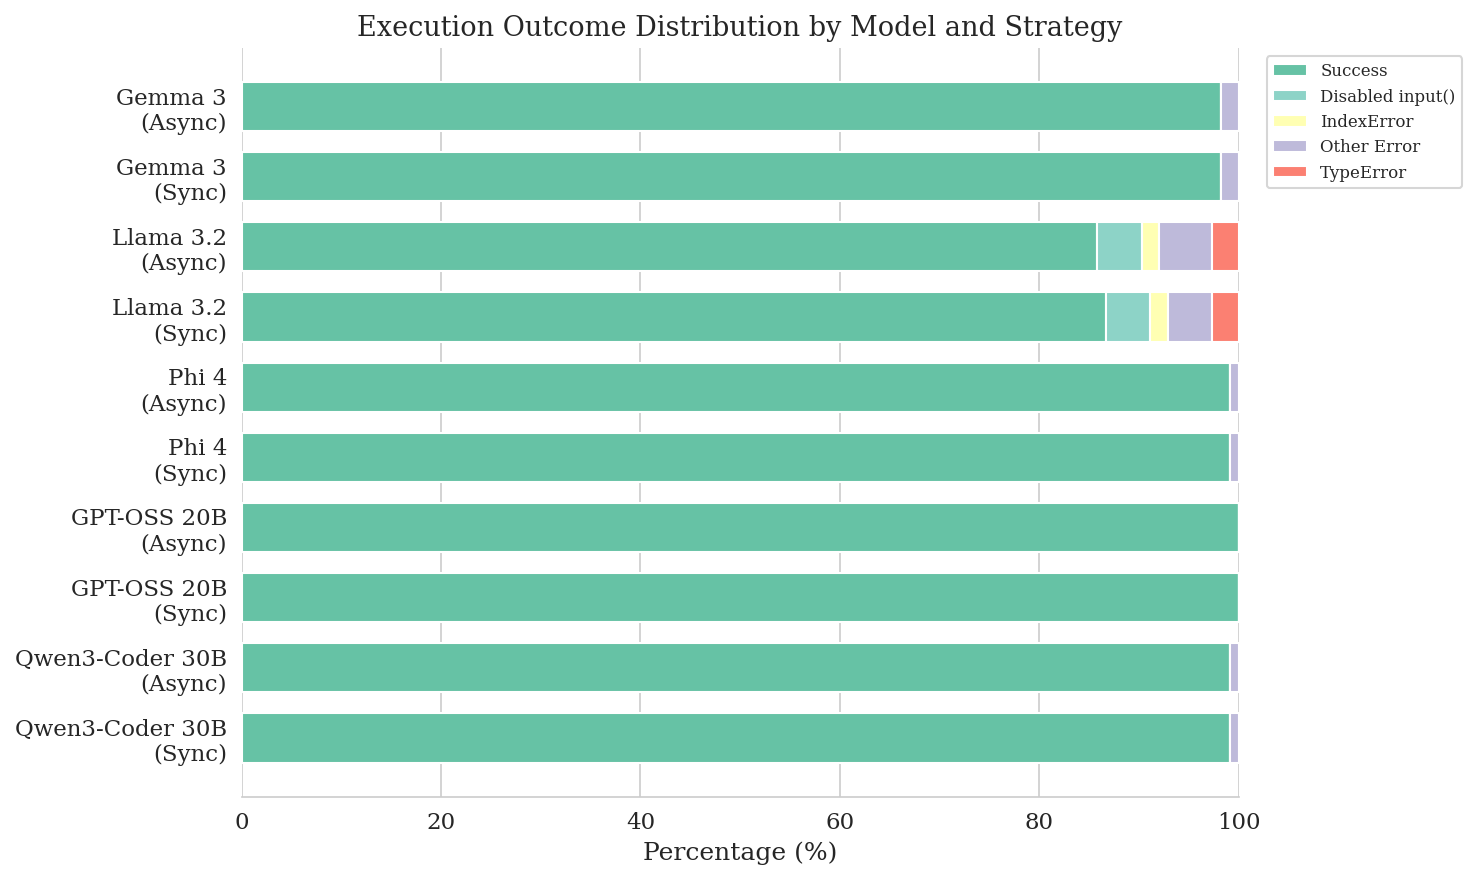

In [44]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 7 — Execution Outcome Distribution (Stacked Horizontal Bar)
# ══════════════════════════════════════════════════════════════════════
# Compute percentage breakdown per (Model, Algorithm)
outcome = (
    df.groupby(["ModelLabel", "Algorithm", "ErrorCategory"])
    .size()
    .reset_index(name="Count")
)
totals = df.groupby(["ModelLabel", "Algorithm"]).size().reset_index(name="Total")
outcome = outcome.merge(totals, on=["ModelLabel", "Algorithm"])
outcome["Pct"] = outcome["Count"] / outcome["Total"] * 100

# Pivot for stacking
piv = outcome.pivot_table(
    index=["ModelLabel", "Algorithm"], columns="ErrorCategory",
    values="Pct", fill_value=0,
)
# Ensure "Success" is first, then sort remaining
cols = ["Success"] + sorted([c for c in piv.columns if c != "Success"])
cols = [c for c in cols if c in piv.columns]
piv = piv[cols]

# Reindex to desired order
idx = pd.MultiIndex.from_product([MODEL_ORDER, ALGO_ORDER], names=["ModelLabel", "Algorithm"])
piv = piv.reindex(idx, fill_value=0)

# Color palette for error categories
cat_colors = {"Success": "#66c2a5"}
other_cats = [c for c in cols if c != "Success"]
other_palette = sns.color_palette("Set3", len(other_cats))
for cat, color in zip(other_cats, other_palette):
    cat_colors[cat] = color

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{m}\n({a})" for m, a in piv.index]
bottom = np.zeros(len(piv))

for col in cols:
    vals = piv[col].values
    bars = ax.barh(labels, vals, left=bottom, label=col,
                   color=cat_colors.get(col, "#cccccc"), edgecolor="white", height=0.7)
    bottom += vals

ax.set_xlabel("Percentage (%)")
ax.set_title("Execution Outcome Distribution by Model and Strategy")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.invert_yaxis()
sns.despine(left=True)

fig.tight_layout()
fig.savefig(IMAGES_DIR / "error_distribution.png")
print("Saved images/error_distribution.png")
plt.show()

Saved images/summary_heatmap.png


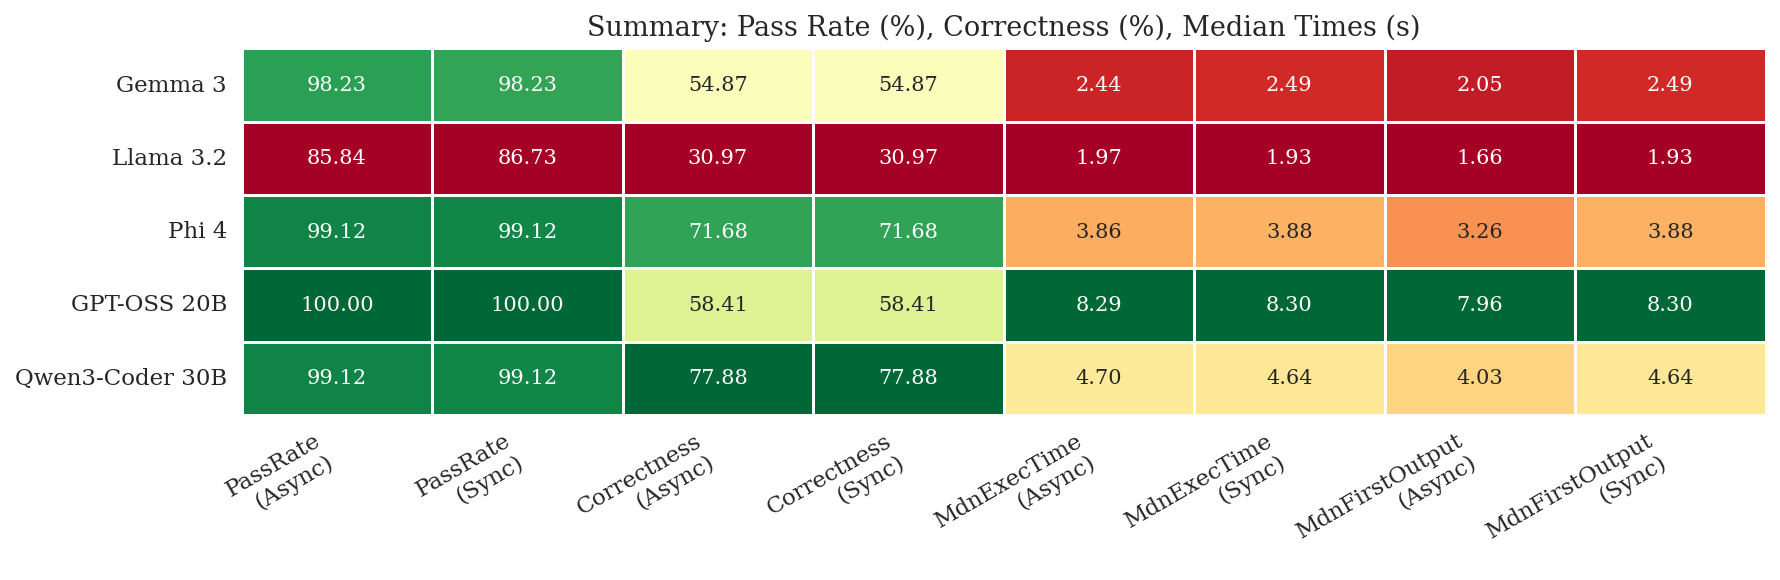

In [45]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 8 — Summary Heatmap (compact overview)
# ══════════════════════════════════════════════════════════════════════
heat_data = (
    df.groupby(["ModelLabel", "Algorithm"])
    .agg(
        PassRate=("ErrorOccurred", lambda x: (1 - x.mean()) * 100),
        Correctness=("CorrectOutput", lambda x: x.mean() * 100),
        MdnExecTime=("ExecutionTime", "median"),
        MdnFirstOutput=("FirstOutput", "median"),
    )
    .round(2)
)

# Unstack Algorithm into columns
heat_wide = heat_data.unstack("Algorithm")
# Flatten multi-level columns
heat_wide.columns = [f"{metric}\n({algo})" for metric, algo in heat_wide.columns]
heat_wide = heat_wide.reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(12, 4))
# Normalize each column independently for display
heat_norm = heat_wide.copy()
for col in heat_norm.columns:
    mn, mx = heat_norm[col].min(), heat_norm[col].max()
    if mx > mn:
        heat_norm[col] = (heat_norm[col] - mn) / (mx - mn)
    else:
        heat_norm[col] = 0.5

sns.heatmap(
    heat_norm, annot=heat_wide.values, fmt=".2f",
    cmap="RdYlGn", ax=ax, linewidths=0.5, cbar=False,
    annot_kws={"fontsize": 10},
)
ax.set_title("Summary: Pass Rate (%), Correctness (%), Median Times (s)", fontsize=13)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(IMAGES_DIR / "summary_heatmap.png")
print("Saved images/summary_heatmap.png")
plt.show()

In [46]:
# ══════════════════════════════════════════════════════════════════════
# SUMMARY — List all generated artifacts
# ══════════════════════════════════════════════════════════════════════
print("=" * 60)
print("GENERATED ARTIFACTS")
print("=" * 60)
print("\nTables (CSV):")
for f in sorted(TABLES_DIR.glob("*.csv")):
    print(f"  {f}")
print("\nFigures (PNG, 300 DPI):")
for f in sorted(IMAGES_DIR.glob("*.png")):
    print(f"  {f}")
print(f"\nTotal: {len(list(TABLES_DIR.glob('*.csv')))} tables, "
      f"{len(list(IMAGES_DIR.glob('*.png')))} figures")

GENERATED ARTIFACTS

Tables (CSV):
  tables\error_breakdown.csv
  tables\pass_correctness.csv
  tables\statistical_tests.csv
  tables\summary_statistics.csv

Figures (PNG, 300 DPI):
  images\correctness_barplot.png
  images\delta_first_output_boxplot.png
  images\error_distribution.png
  images\execution_time_violin.png
  images\first_output_ecdf.png
  images\first_output_violin.png
  images\speedup_ratio_barplot.png
  images\summary_heatmap.png

Total: 4 tables, 8 figures
